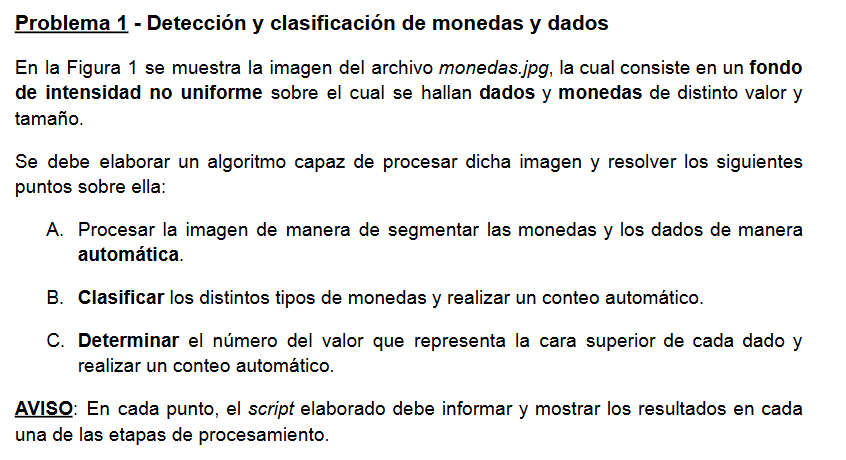

In [62]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# PARTE A

In [63]:
img = cv2.imread('img/monedas.jpg')

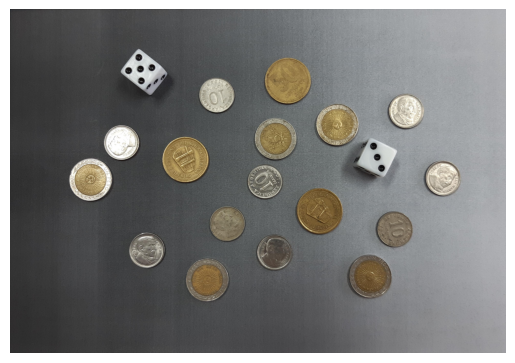

In [64]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [65]:
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

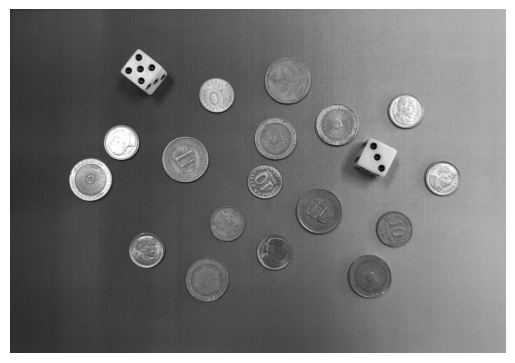

In [66]:
plt.imshow(img_gris, cmap='gray')
plt.axis('off')
plt.show()

In [67]:
# filtro gaussiano
img_gris_blur = cv2.GaussianBlur(img_gris, (9, 9), 2)

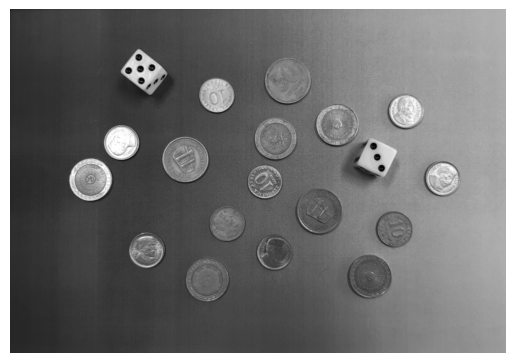

In [68]:
plt.imshow(img_gris_blur, cmap='gray')
plt.axis('off')
plt.show()

umbralado de la practica pdi_u3_segmentacion.py

con  cv2.threshold()

https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57

100.0
uint8
[  0 255]


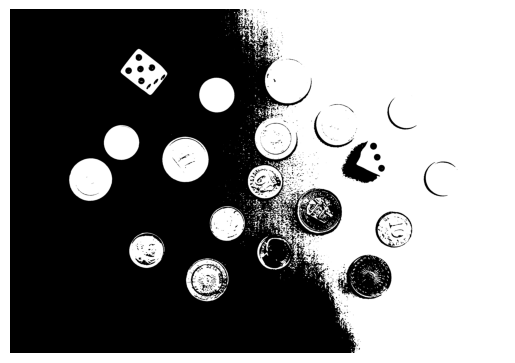

In [69]:
th_out, img_umbralado = cv2.threshold(img_gris_blur, thresh=100, maxval=255, type=cv2.THRESH_BINARY)
print(th_out)
print(img_umbralado.dtype)
print(np.unique(img_umbralado))
plt.imshow(img_umbralado, cmap='gray')
plt.axis('off')
plt.show()

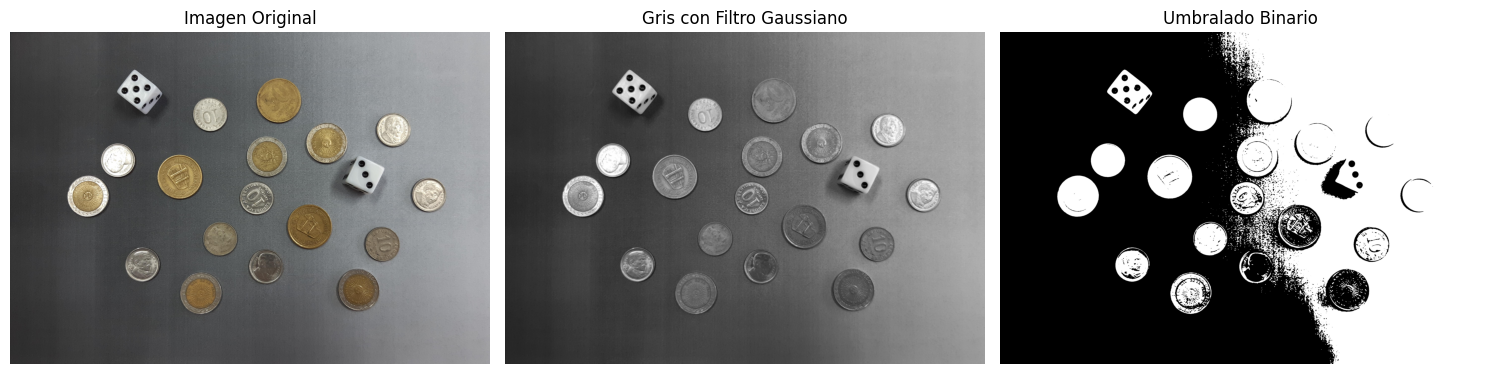

In [70]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gris_blur, cmap='gray')
plt.title('Gris con Filtro Gaussiano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_umbralado, cmap='gray')
plt.title('Umbralado Binario')
plt.axis('off')

plt.tight_layout()
plt.show()


 cv2.adaptiveThreshold(

   imagen_fuente (grises),

   valor_maximo (255, blanco),

   metodo_adaptativo (cv2.ADAPTIVE_THRESH_GAUSSIAN_C -> mejor para iluminación variable),

   tipo_umbral (cv2.THRESH_BINARY_INV -> Invertido, queremos objetos blancos),

   tamano_bloque (ej. 31x31 píxeles, debe ser impar),
   
   C (constante a restar de la media, ajusta la sensibilidad)
 )

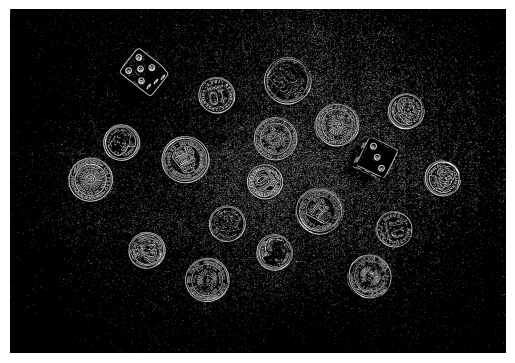

In [71]:
# hay que hacer umbralado local (vecinos)
img_umbralado_oscuro = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,   # objetos oscuros
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.axis('off')
plt.show()

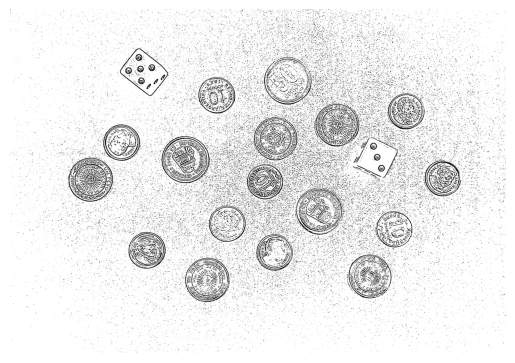

In [72]:
# hay que hacer umbralado local (vecinos)
img_umbralado_blancos = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,   # objetos blancos
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

plt.imshow(img_umbralado_blancos, cmap='gray')
plt.axis('off')
plt.show()

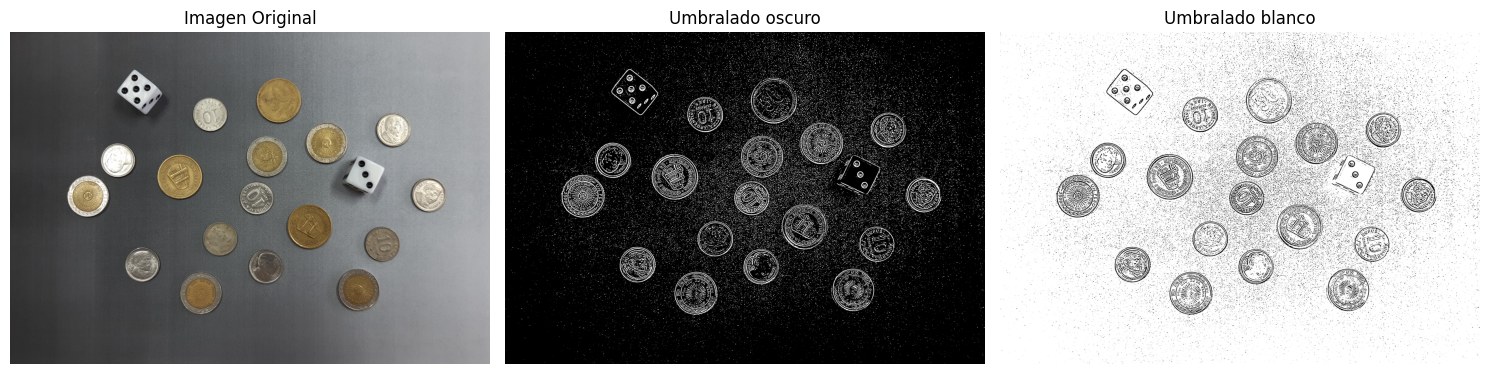

In [73]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.title('Umbralado oscuro')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Umbralado blanco')
plt.axis('off')

plt.tight_layout()
plt.show()

In [74]:
# componentes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    img_umbralado_blancos,
    connectivity=8,
    ltype=cv2.CV_32S
)
print(num_labels, labels, stats, centroids)

252 [[1 0 0 ... 2 2 2]
 [0 0 0 ... 2 2 2]
 [0 0 2 ... 2 2 2]
 ...
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]] [[      0       0    3871    2681  810303]
 [      0       0       1       1       1]
 [      0       0    3871    2681 9196179]
 ...
 [   1541    2245      36      16     238]
 [   1599    2245      13       7      30]
 [   2836    2246       1       1       1]] [[2070.73471529 1257.08243336]
 [   0.            0.        ]
 [1952.59443819 1354.86505722]
 [2489.            0.        ]
 [3222.           71.        ]
 [1121.           95.        ]
 [2158.           94.        ]
 [2480.          251.5       ]
 [1051.3208945   493.22502561]
 [2015.          340.        ]
 [3259.          353.        ]
 [1004.26161369  368.75550122]
 [ 997.85526316  379.88157895]
 [1010.14583333  381.94791667]
 [1020.23076923  384.92307692]
 [1002.28571429  392.92307692]
 [1111.55263158  446.85087719]
 [1021.79381443  460.64742268]
 [1088.96629213  454.12359551]
 [1099.57983193  461.00

In [75]:
copia_img = img.copy()

In [76]:
def encontrar_figuras(imagen, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA):

    objetos_contados = 0 

    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]


        if area >= AREA_MINIMA_VALIDA:
    
            objetos_contados += 1 

            cv2.rectangle(imagen, (x, y), (x + w, y + h), (0, 255, 0), 2)

            (cX, cY) = centroids[i]
            cv2.putText(imagen, str(objetos_contados), (int(cX) - 10, int(cY)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)


    print(f"Se encontraron {objetos_contados} objetos válidos")

encontrar_figuras(copia_img, 410, 3500)

Se encontraron 19 objetos válidos


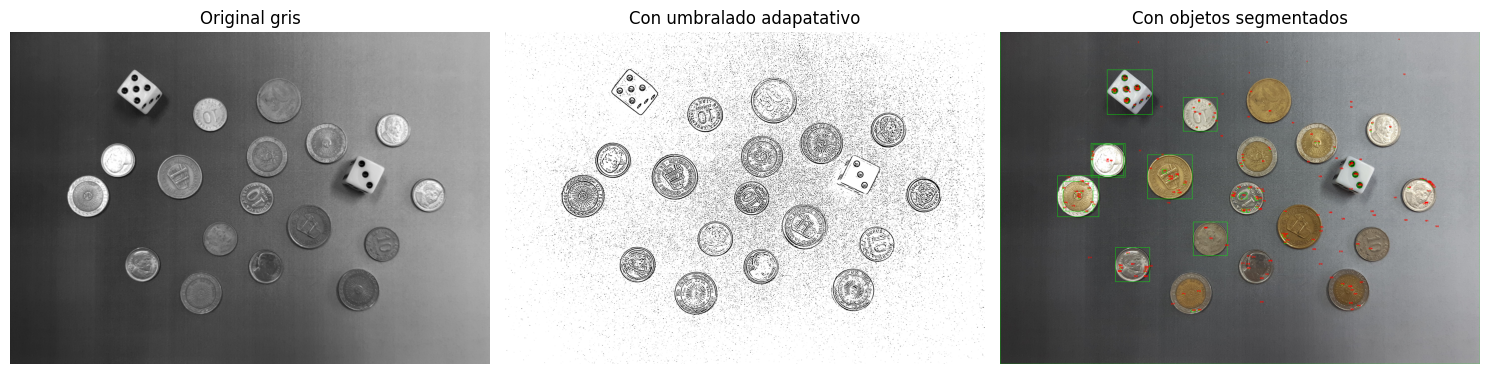

In [78]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(img_gris_blur, cmap='gray')
plt.title('Original gris')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Con umbralado adapatativo')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(copia_img, cv2.COLOR_BGR2RGB))
plt.title('Con objetos segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()

In [79]:
img_gris = cv2.cvtColor(copia_img, cv2.COLOR_BGR2GRAY)

_, img_binaria = cv2.threshold(img_gris, 127, 255, cv2.THRESH_BINARY) 

contours, hierarchy = cv2.findContours(img_binaria, cv2.RETR_LIST, cv2.RETR_EXTERNAL)
